- Apply algorithms and models. This includes
    Choose three algorithms (Linear Regression, Decision Trees and Random Forest Regression) to predict the price of properties.
  
        1. Part A: Provide Results, Accuracy Score of Prediction and Visualization.
        2. Part B: Explain what and why did you choose these algorithms for this particular problem. Explain which algorithm performs better for this dataset.

  
- Use SHAP Values to explain how your machine learning model works. 
- Explain if you know any other techniques like SHAP values to increase transparency and interpretability of machine learning models. 

In [121]:
import pandas as pd
df = pd.read_csv ("M5 Sales_Properties.csv")
df.head()

,Date_Property_Sold,Postal_Code,Property-Price,Property_Type,Number_Bedrooms
0,2/7/2007 0:00,2607,525000,house,4
1,2/27/2007 0:00,2906,290000,house,3
2,3/7/2007 0:00,2905,328000,house,3
3,3/9/2007 0:00,2905,380000,house,4
4,3/21/2007 0:00,2906,310000,house,3


**Algorithm 1: Linear Regression**

In [122]:
# algorithm 1: Linear Regression
# import all libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [123]:
# clean data: check for null & duplicated
print (df.info())
# duplicated rows
duplicated = df.duplicated().sum()
print(f"Duplicate rows: {duplicated}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date_Property_Sold  29580 non-null  object
 1   Postal_Code         29580 non-null  int64 
 2   Property-Price      29580 non-null  int64 
 3   Property_Type       29580 non-null  object
 4   Number_Bedrooms     29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB
None
Duplicate rows: 0


In [124]:
# convert date_property_sold
df["Date_Property_Sold"] = pd.to_datetime(df["Date_Property_Sold"])

df["year"] = df["Date_Property_Sold"].dt.year
df["month"] = df["Date_Property_Sold"].dt.month

# Drop original date
df.drop("Date_Property_Sold", axis=1, inplace=True)

In [125]:
# convert property type
df = pd.get_dummies(df, columns=["Property_Type"], drop_first=True)

#postal code
df["Postal_Code"] = df["Postal_Code"].astype("category").cat.codes

In [126]:
df.columns

Index(['Postal_Code', 'Property-Price', 'Number_Bedrooms', 'year', 'month',
       'Property_Type_unit'],
      dtype='object')

**explanation**

Step by step:
- load data
- checked for null and duplicated rows, there were none
- 2 of the features will have to be converted since the machine cannot read dates or postal codes.
- I separated the dates into year an donth and dropped the original column
- Printed `df.columns` to check what columns i have now

In [127]:
# Assign X and Y
X = df[["year", "month", "Postal_Code", "Number_Bedrooms", "Property_Type_unit"]]
y = df["Property-Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**explanation**

- assigned feature and target
- Property Price is the thing we are predicting, everything else are features
- Split into 80% training 20% testing

In [128]:
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

**explanation**

- scaling needed when you look at "numbr of bedrooms" compared to "year" and "property type unit".
- Inquired ChatGPT about scaling Postal code and times, since I wasn't sure if it make sense to scale these. According to ChatGPT, it is fine if we scale it for this problem ("ChatGPT", 5.2, 2026).

In [129]:
# train the model
model = LinearRegression()
model.fit(X_train, y_train)

# See what the model learned
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)
print("Intercept:", model.intercept_)

              Feature    Coefficient
0                year   61485.686469
1               month    9207.016793
2         Postal_Code -108106.266899
3     Number_Bedrooms  156047.916199
4  Property_Type_unit  -17248.016588
Intercept: 610702.7653820147


**explanation**

- listed coefficients for each feature
- for example, with each number of bedroom of increase, the propery price would increase by $156047

In [130]:
# predict
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(comparison.head())

       Actual      Predicted
20589  668000  492071.428727
19391  350000  493366.785326
16181  586000  452622.469336
22902  685000  655392.709591
28561  242000  467915.592009


**explanation**

- results showed the predicted property price
- uses the coefficient to estimate prices 

In [131]:
# evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", round(r2, 2))

MAE: 127270.34396716728
RMSE: 192477.81400884496
R² Score: 0.45


**explanation**

MAE → average prediction error
RMSE → penalizes large errors more
R² score → how well model explains data
(closer to 1 = better)

- result has shown that the accuracy is low

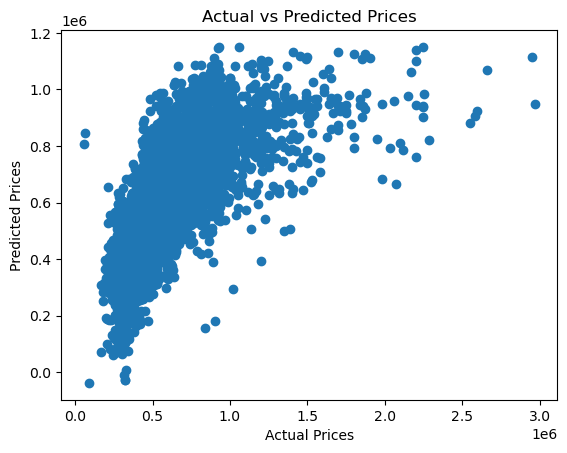

In [132]:
#plot
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

**explanation**

- first plot shows a comparison between actual prices vs predicted prices
- a diagonal shape generally means great accuracy, as the plot shows, its largely gathered to the left, model is predicting too high

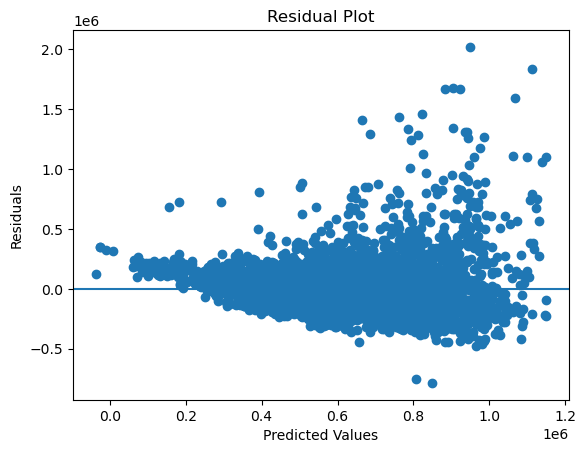

In [133]:
#residuals
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**explanation**

- for the residual plot, closer to the line would mean smaller error
- As the plot shows, the predicted values are very scattered

              Feature    Coefficient
3     Number_Bedrooms  156047.916199
0                year   61485.686469
1               month    9207.016793
4  Property_Type_unit  -17248.016588
2         Postal_Code -108106.266899


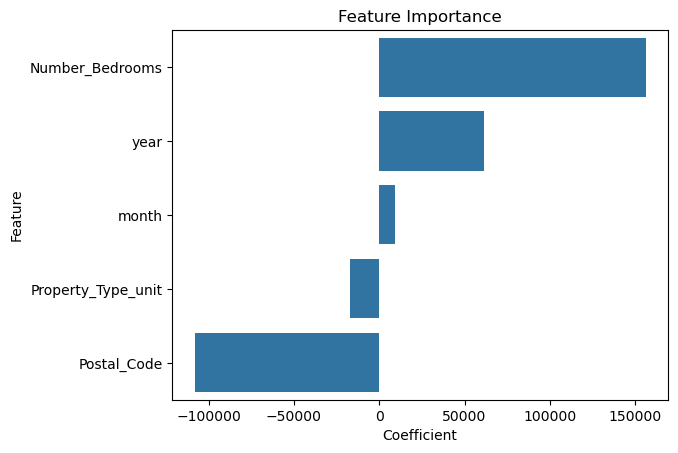

In [134]:
# feature importance
importance = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print(importance)

sns.barplot(x="Coefficient", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

**explanation**

- this plot shows the most important feature in predicting the property price
- Number of bedrooms proves to be the most important factor in the prediction

**algorithm 2: Decision Trees**

In [162]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [163]:
#decision tree regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

In [164]:
# evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred))
r2_dt= r2_score(y_test, y_pred)

print("Decision Tree Results:")
print("MAE:", mae)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Results:
MAE: 106582.81437559097
RMSE: 194532.2077360629
R²: 0.4399608925617612


**explanation**

- Data was already processed with linear regression
- Moved on to training and predicting using Decision Tree
- As results showed, Accuracy score ($R^2$) is also low

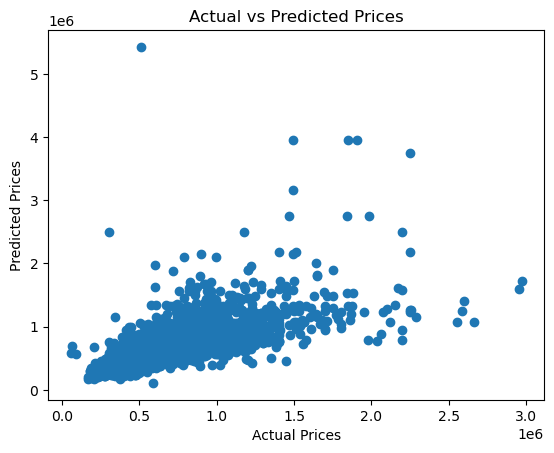

In [165]:
# plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

**explanation**
- the plot is showing the model is likely underpredicting the prices

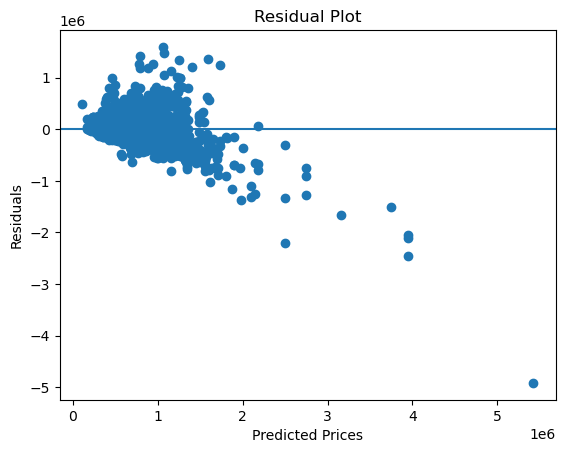

In [166]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**explanation**

- As shown, the result is stil scattered and proving the margin of error is large

              Feature  Importance
2         Postal_Code    0.397113
3     Number_Bedrooms    0.319817
0                year    0.145576
1               month    0.119519
4  Property_Type_unit    0.017975


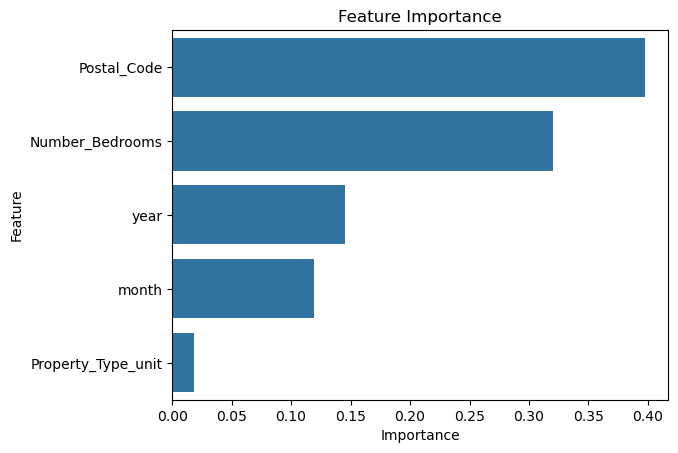

In [167]:
# feature importance
importance = pd.DataFrame({
    "Feature":     X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

**explanation**

- for decision tree, it's shown that the feature that matters the most when it comes to predicting property prices is the zip code, folliwng by number of bedrooms

**algorithm 3: Random Forest Regression**

In [142]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

estimator = 100 means 100 trees. More trees = more stable results but slower training.

In [143]:
#predict
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**explanation**

- same process, but using Random Forest this time

In [144]:
#evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf= r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results:
MAE: 100058.3674938088
RMSE: 159308.80015241003
R²: 0.62440927679954


**explanation**

- as shown, the accuracy score has improved compared to linear regression and decision tree

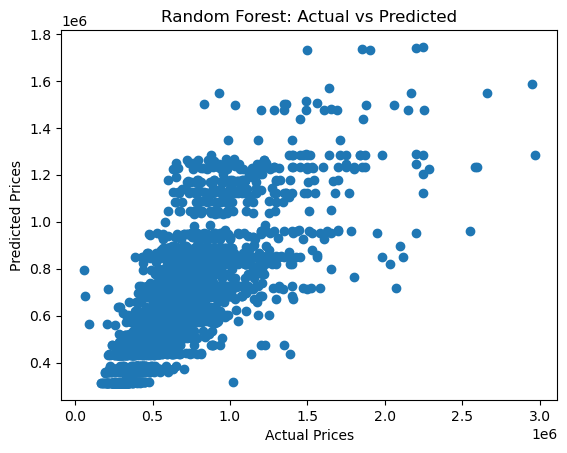

In [145]:
#plot

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

**explanation**

- I can see more of a diagonal shape with random forest, however the accuracy is still not perfect

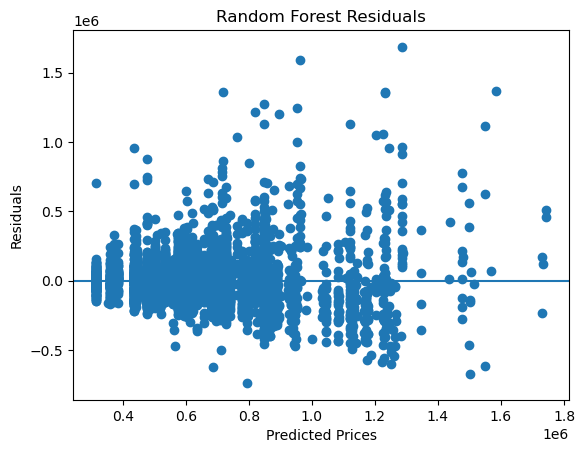

In [146]:
#residual plot
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals")
plt.show()

In [148]:
#feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

              Feature  Importance
3     Number_Bedrooms    0.471148
2         Postal_Code    0.426893
0                year    0.095544
4  Property_Type_unit    0.005430
1               month    0.000985


**explanation**

- feature importance ranking shows number of bedroom to be the most important feature

**compare models**

In [149]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2": [r2, r2_dt, r2_rf],
    "RMSE": [rmse, rmse_dt, rmse_rf]
})

print(results)

               Model        R2           RMSE
0  Linear Regression  0.451727  192477.814009
1      Decision Tree  0.439961  194532.207736
2      Random Forest  0.624409  159308.800152


**explanation**

- when compared, Random forest proved to be more accurate than decision tree and linear regression

**Use SHAP Values to explain how your machine learning model works.**

In [168]:
# feature names
print(X.columns)

Index(['year', 'month', 'Postal_Code', 'Number_Bedrooms',
       'Property_Type_unit'],
      dtype='object')


In [169]:
X_test_named = pd.DataFrame(X_test, columns=X.columns)

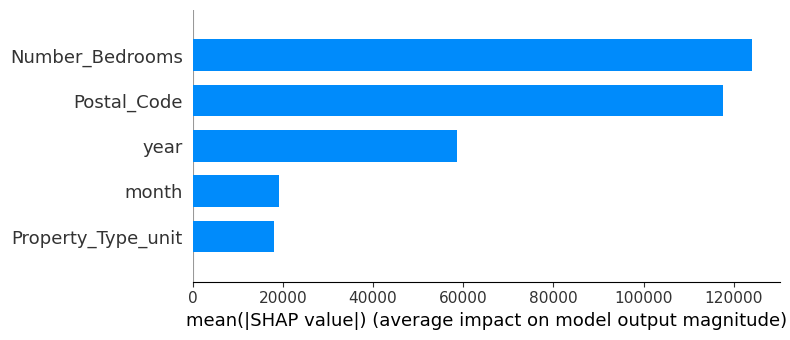

In [170]:
import shap
# Decision Tree
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_test_named)
shap.summary_plot(shap_values, X_test_named, plot_type="bar")

In [157]:
# Random FOrest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_named)

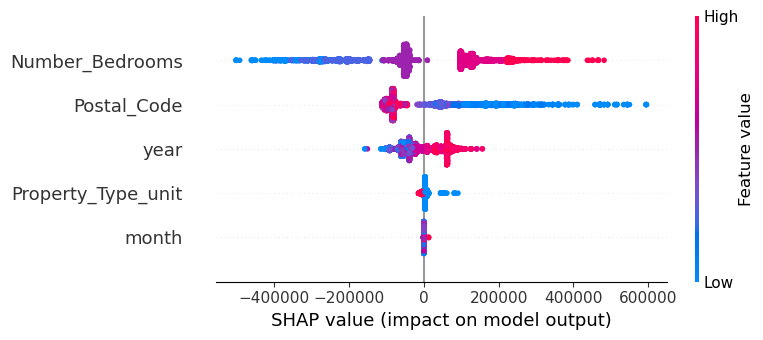

In [158]:
#summary
shap.summary_plot(shap_values, X_test_named)

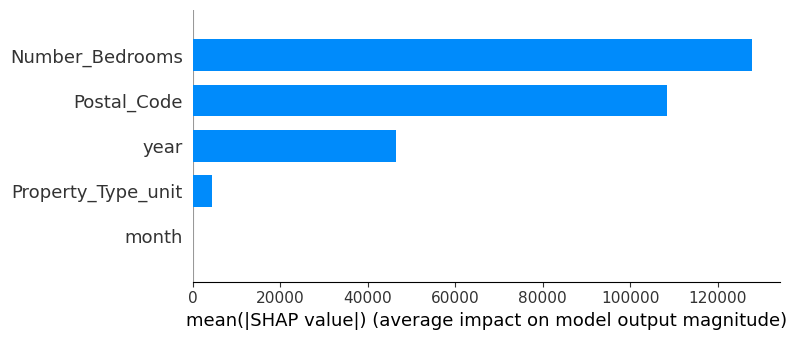

In [159]:
shap.summary_plot(shap_values, X_test_named, plot_type="bar")

**explanation**
- SHAP values were applied to the Random Forest model and Decision Tree to interpret how each feature contributes to the predicted property price.
- Decision Tree: Number of Bedroom contributes most
  - this was different than when I did feature importance earlier, which said 'Postal code' was more important. SHAP measures the actual contribution, so the number of bedroom is more accurate.
- Random Forest: NUmber of Bedroom contributes most
- I didn't use SHAP on Linear regression since ChatGPT had suggested that Linear regression has COefficients, which was already interpretable.
- I also changed the feature names back into a dataframe so the actual feature names would show, instead of numbers.

**Other interpretability techniques**

1. feature importance (which was used in this assignment)
2. Local Interpretable Model-agnostic Explanations (LIME)
   - according to ChatGPT, LIME explains 1 prediction at a time and works with all models
   - for example, it answers the question "“Why did the model predict THIS price for THIS specific house?” ("ChatGPT", 5.2, 2026)

**Reference list:**
OpenAI. (2026). ChatGPT (5.2) [Large language model]. https://chat.openai.com/